In [2]:
import json

import pandas as pd
import numpy as np
import ast
import os

from typing import Union, List

# Load Impact DF

In [3]:
def try_literal_eval(x):
    if isinstance(x, str):
        x = x.strip()
        if (x.startswith("[") and x.endswith("]")) or \
           (x.startswith("{") and x.endswith("}")) or \
           (x.startswith("(") and x.endswith(")")):
            try:
                return ast.literal_eval(x)
            except (ValueError, SyntaxError):
                return x
    return x

In [4]:
dataset_dir = "/home/yishin/keith/patent_research/model_io"

In [ ]:
Impact_df = pd.read_csv(os.path.join(dataset_dir, "2_Impact_Sub_Crops.csv"), encoding="utf-8")
Impact_df = Impact_df.map(try_literal_eval)

Impact_df.head()

,title,caption,image_paths,best_fig_desc,Loc_class,main_class,sub_class,keywords,original_order,crop_paths
0,3D flower-shaped throw pillow,The image is a black and white drawing of a 3D...,[impact_dataset/2022/USD0954470-20220614/USD09...,{'FIG. 1': 'FIG. 1 is a front and top perspect...,{06-13},6,13,"[pillow, flower, stem, leaves]",342.0,[figure_crops/342_3D flower-shaped throw pillo...
1,3D printer extruder,The image is a black and white drawing of a 3D...,[impact_dataset/2022/USD0955471-20220621/USD09...,{'FIG. 1': 'FIG. 1 is a perspective view of a ...,{18-02},18,2,"[barrel, nozzle, element, heater]",2078.0,[figure_crops/2078_3D printer extruder/FIG_4.j...
2,3D wall panel,The image is a black and white geometric shape...,[impact_dataset/2022/USD0947417-20220329/USD09...,{'FIG. 1': 'FIG. 1 is a front and top elevatio...,{25-01},25,1,"[panel, shape, surface, room, design, element,...",2787.0,[figure_crops/2787_3D wall panel/FIG_3.jpg]
3,Absorber for a loudspeaker,"The image shows a round shape, which is a comm...",[impact_dataset/2022/USD0940115-20220104/USD09...,{'FIG. 2': 'FIG. 2 is a bottom perspective vie...,{14-01},14,1,"[round shape, material, absorber, loudspeaker]",1531.0,[figure_crops/1531_Absorber for a loudspeaker/...
4,Abutment holder for dental implants,The image is a black and white drawing of an A...,[impact_dataset/2022/USD0967427-20221018/USD09...,{'FIG. 1': 'FIG. 1 is a perspective view of an...,{24-03},24,3,"[cylinder, holder, abutment, grip, arm, base]",2749.0,[figure_crops/2749_Abutment holder for dental ...


In [42]:
duplicates = Impact_df[Impact_df.duplicated(subset="title", keep=False)]
duplicates.sort_values("title")

,title,caption,image_paths,best_fig_desc,Loc_class,main_class,sub_class,keywords,original_order,crop_paths
13,Acoustic panel,"The image is a square shape, and it is a drawi...",[impact_dataset/2022/USD0971448-20221129/USD09...,"{'FIG. 1': 'FIG. 1 is a front, right and top p...",{25-01},25,1,"[rectangle, frame, panel, surface]",2772.0,[figure_crops/2772_Acoustic panel/FIG_4.jpg]
14,Acoustic panel,"The image is a white cube, which is the shape ...",[impact_dataset/2022/USD0971451-20221129/USD09...,"{'FIG. 1': 'FIG. 1 is a front, right and top p...",{25-01},25,1,"[rectangle, frame, panel, surface]",2773.0,[figure_crops/2773_Acoustic panel/FIG_4.jpg]
15,Acoustic panel,The image is rectangular in shape. Acoustic pa...,[impact_dataset/2022/USD0969351-20221108/USD09...,{'FIG. 1': 'FIG. 1 is a side perspective view ...,{25-01},25,1,"[rectangle, frame, panel, surface]",2754.0,"[figure_crops/2754_Acoustic panel/FIG_4.jpg, f..."
18,Adapter for camera lens,The image is a white drawing of a camera lens ...,[impact_dataset/2022/USD0960960-20220816/USD09...,{'FIG. 7': 'FIG. 7 is a Front Perspective view...,"{16-01, 16-05}",16,5,NaN,NaN,[figure_crops/2013_Adapter for camera lens/FIG...
19,Adapter for camera lens,The image is a white drawing of a camera lens ...,[impact_dataset/2022/USD0960960-20220816/USD09...,{'FIG. 7': 'FIG. 7 is a Front Perspective view...,"{16-01, 16-05}",16,5,"[lens mount, ring, aperture control]",2013.0,NaN
...,...,...,...,...,...,...,...,...,...,...
3240,Wireless earphone,The image is a white drawing of a pair of wire...,[impact_dataset/2022/USD0958773-20220726/USD09...,{'FIG. 1': 'FIG. 1 is a front perspective view...,{14-01},14,1,"[earpieces, headband, microphone, speaker, bat...",1424.0,[figure_crops/1424_Wireless earphone/FIG_1.jpg]
3252,Wrench,The image is a black and white drawing of a wr...,[impact_dataset/2022/USD0957904-20220719/USD09...,{'FIG. 1': 'FIG. 1 is a perspective view of a ...,{08-05},8,5,"[handle, shank, socket]",680.0,"[figure_crops/680_Wrench/FIG_2.jpg, figure_cro..."
3253,Wrench,"The image is a tall, thin, and rectangular sha...",[impact_dataset/2022/USD0952425-20220524/USD09...,"{'FIG. 1': 'FIG. 1 is a top, front, right pers...",{08-05},8,5,"[handle, shank, socket]",704.0,"[figure_crops/704_Wrench/FIG_3.jpg, figure_cro..."
3254,Wrist watch,"The image is square-shaped, and the wristwatch...",[impact_dataset/2022/USD0939970-20220104/USD09...,{'?': '1.2 : Rear View'},{10-02},10,2,"[case, dial, hands, crystal, lens, strap, band...",891.0,[]


In [45]:
Impact_df.index[Impact_df["title"].str.lower() == "wrench"].tolist()

[3252, 3253]

In [17]:
Impact_df["title"].iloc[100]

'Ashtray'

In [18]:
Impact_df["crop_paths"].iloc[10]

['figure_crops/2297_Accessory mount/FIG_5.jpg',
 'figure_crops/2297_Accessory mount/FIG_6.jpg',
 'figure_crops/2297_Accessory mount/FIG_7.jpg',
 'figure_crops/2297_Accessory mount/FIG_8.jpg']

# SAM

## Detect Region Cells

In [19]:
import os
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from tqdm import tqdm

In [20]:
from transformers import pipeline
import numpy as np
import cv2

mask_generator = pipeline(
    "mask-generation",
    model="facebook/sam-vit-huge",
    device="cuda"
)

def get_sam_cells(image_path, points_per_side=32, min_mask_area=2000, max_mask_area_pct=0.7):
    img = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(image_rgb)
    h, w = image_rgb.shape[:2]
    total_area = h * w

    outputs = mask_generator(pil_image, points_per_side=points_per_side)

    grid_cells = []
    for i, mask in enumerate(outputs["masks"]):
        mask_np = np.array(mask)
        area = mask_np.sum()

        if area < min_mask_area:
            continue
        if area > total_area * max_mask_area_pct:   # skip overly large masks
            continue

        ys, xs = np.where(mask_np > 0)
        x1, y1, x2, y2 = int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())

        grid_cells.append({
            "id": len(grid_cells),
            "row": 0,
            "col": len(grid_cells),
            "bbox": (x1, y1, x2, y2),
            "mask": mask_np,
            "confidence_score": 1.0
        })

    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 80, 150)

    return image_rgb, grid_cells, edges

/home/yishin/miniconda3/envs/patent/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
def deduplicate_masks(grid_cells, iou_threshold=0.7):
    def compute_iou(a, b):
        ax1, ay1, ax2, ay2 = a["bbox"]
        bx1, by1, bx2, by2 = b["bbox"]
        ix1, iy1 = max(ax1, bx1), max(ay1, by1)
        ix2, iy2 = min(ax2, bx2), min(ay2, by2)
        if ix1 >= ix2 or iy1 >= iy2:
            return 0.0
        inter = (ix2 - ix1) * (iy2 - iy1)
        area_a = (ax2 - ax1) * (ay2 - ay1)
        area_b = (bx2 - bx1) * (by2 - by1)
        return inter / (area_a + area_b - inter)

    kept = []
    for cell in sorted(grid_cells, key=lambda c: c["mask"].sum(), reverse=True):
        if not any(compute_iou(cell, k) > iou_threshold for k in kept):
            kept.append(cell)
    return kept

In [22]:
def draw_grid_cells(image_rgb, grid_cells):
    img = Image.fromarray(image_rgb)
    output = img.copy()
    draw = ImageDraw.Draw(output)

    for cell in grid_cells:
        x1, y1, x2, y2 = cell["bbox"]

        draw.rectangle(
            (x1, y1, x2, y2),
            outline=(255, 0, 0),
            width=3
        )

    return output

In [23]:
def get_fig_id(image_path):
    return os.path.splitext(os.path.basename(image_path))[0]

In [24]:
def make_json_safe_region(cell):
    """
    Keep bbox and metadata, but do not store full mask array in the DataFrame.
    Store mask area instead.
    """
    return {
        "id": int(cell["id"]),
        "bbox": tuple(map(int, cell["bbox"])),
        "area": int(cell["mask"].sum()) if "mask" in cell else None
    }

In [25]:
def generate_sam_regions_for_crop_paths(crop_paths):
    if not isinstance(crop_paths, list):
        return {}

    fig_regions = {}

    for img_path in crop_paths:
        fig_id = get_fig_id(img_path)

        image_rgb, grid_cells, edges = get_sam_cells(img_path)
        grid_cells = deduplicate_masks(grid_cells)

        fig_regions[fig_id] = [
            make_json_safe_region(cell)
            for cell in grid_cells
        ]

    return fig_regions

In [26]:
tqdm.pandas()

In [46]:
test_df = Impact_df.iloc[3252:3254].copy()

test_df["regions"] = test_df["crop_paths"].progress_apply(
    generate_sam_regions_for_crop_paths
)

100%|██████████| 2/2 [00:07<00:00,  3.74s/it]


In [47]:
test_df

,title,caption,image_paths,best_fig_desc,Loc_class,main_class,sub_class,keywords,original_order,crop_paths,regions
3252,Wrench,The image is a black and white drawing of a wr...,[impact_dataset/2022/USD0957904-20220719/USD09...,{'FIG. 1': 'FIG. 1 is a perspective view of a ...,{08-05},8,5,"[handle, shank, socket]",680.0,"[figure_crops/680_Wrench/FIG_2.jpg, figure_cro...","{'FIG_2': [{'id': 1, 'bbox': (197, 894, 300, 1..."
3253,Wrench,"The image is a tall, thin, and rectangular sha...",[impact_dataset/2022/USD0952425-20220524/USD09...,"{'FIG. 1': 'FIG. 1 is a top, front, right pers...",{08-05},8,5,"[handle, shank, socket]",704.0,"[figure_crops/704_Wrench/FIG_3.jpg, figure_cro...","{'FIG_3': [{'id': 3, 'bbox': (21, 20, 722, 263..."


In [51]:
test_df["regions"].iloc[0]

{'FIG_2': [{'id': 1, 'bbox': (197, 894, 300, 1798), 'area': 89405},
  {'id': 0, 'bbox': (156, 2268, 424, 2684), 'area': 79630},
  {'id': 3, 'bbox': (85, 280, 364, 621), 'area': 39462},
  {'id': 4, 'bbox': (198, 895, 298, 1165), 'area': 23944},
  {'id': 2, 'bbox': (198, 1570, 298, 1797), 'area': 19642}],
 'FIG_4': [{'id': 3, 'bbox': (116, 0, 260, 2782), 'area': 328444},
  {'id': 0, 'bbox': (20, 14, 235, 2688), 'area': 241261},
  {'id': 2, 'bbox': (25, 2279, 237, 2685), 'area': 47454},
  {'id': 1, 'bbox': (33, 18, 124, 341), 'area': 29020},
  {'id': 4, 'bbox': (25, 2280, 143, 2375), 'area': 8684}]}

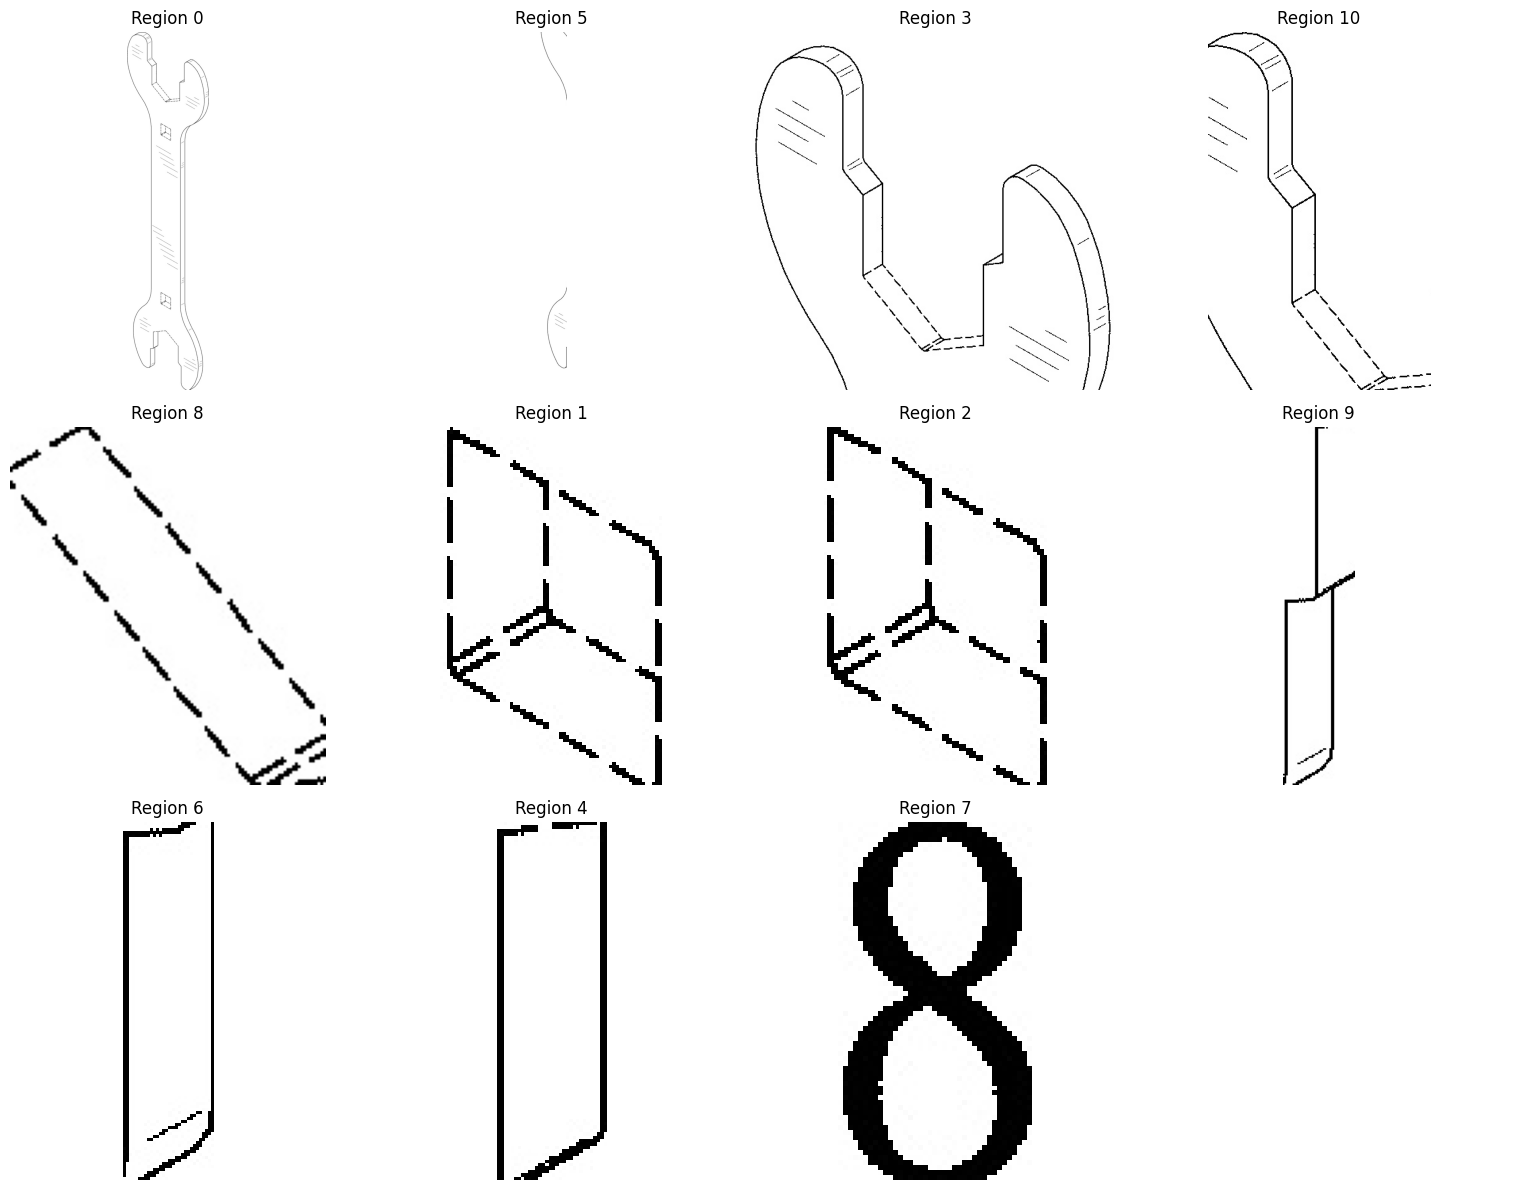

In [59]:
from PIL import Image
import matplotlib.pyplot as plt
import math

row = test_df.iloc[1]

img_path = row["crop_paths"][1]
fig_id = get_fig_id(img_path)
regions = row["regions"][fig_id]

img = Image.open(img_path).convert("RGB")

# Crop each region
crops = []
for region in regions:
    x1, y1, x2, y2 = map(int, region["bbox"])
    crop = img.crop((x1, y1, x2, y2))
    crops.append((region["id"], crop))

# Display as a table/grid
cols = 4
rows = math.ceil(len(crops) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))

# Make axes iterable even if only one row
axes = axes.flatten() if rows > 1 else ([axes] if cols == 1 else axes)

for ax, (rid, crop) in zip(axes, crops):
    ax.imshow(crop)
    ax.set_title(f"Region {rid}")
    ax.axis("off")

# Hide unused cells
for ax in axes[len(crops):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Quadtree Hierarchy

In [60]:
def contains_bbox(parent, child, margin=0):
    px1, py1, px2, py2 = parent
    cx1, cy1, cx2, cy2 = child

    return (
        cx1 >= px1 - margin and
        cy1 >= py1 - margin and
        cx2 <= px2 + margin and
        cy2 <= py2 + margin
    )


def bbox_area(bbox):
    x1, y1, x2, y2 = bbox
    return (x2 - x1) * (y2 - y1)


def build_region_hierarchy(regions, margin=0):
    """
    regions format:
    [
        {"id": 0, "bbox": [x1, y1, x2, y2]},
        ...
    ]
    """

    parent = {}

    for child in regions:
        child_id = child["id"]
        child_bbox = child["bbox"]

        possible_parents = []

        for p in regions:
            parent_id = p["id"]
            parent_bbox = p["bbox"]

            if parent_id == child_id:
                continue

            if contains_bbox(parent_bbox, child_bbox, margin=margin):
                possible_parents.append(p)

        # choose the smallest containing box as direct parent
        if possible_parents:
            direct_parent = min(
                possible_parents,
                key=lambda r: bbox_area(r["bbox"])
            )
            parent[child_id] = direct_parent["id"]
        else:
            parent[child_id] = None

    tree = {r["id"]: [] for r in regions}

    for child_id, parent_id in parent.items():
        if parent_id is not None:
            tree[parent_id].append(child_id)

    roots = [rid for rid, pid in parent.items() if pid is None]

    return parent, tree, roots

In [61]:
def print_tree(node, tree, level=0):
    print("  " * level + f"Region {node}")
    for child in tree[node]:
        print_tree(child, tree, level + 1)

In [62]:
parent, tree, roots = build_region_hierarchy(regions, margin=5)

for root in roots:
    print_tree(root, tree)

Region 0
  Region 1
  Region 2
  Region 9
    Region 6
  Region 4
Region 5
Region 3
  Region 10
    Region 8
Region 7
